In [4]:
import sys
print(sys.executable)

/Users/bhavyavardhansingh/Downloads/DSA/Brain Tumor/.venv/bin/python


In [18]:
import os

BASE_DIR = os.path.abspath("..")  # goes to project root

In [19]:
model_path = os.path.join(BASE_DIR, "models/classification/efficientnet_b0_best.pth")
image_path = os.path.join(BASE_DIR, "data/Testing/glioma/Te-gl_0010.jpg")
output_path = os.path.join(BASE_DIR, "outputs/gradcam.jpg")

In [5]:
import cv2
print("cv2 working")

cv2 working


In [6]:
import torch
print(torch.__version__)

2.8.0


In [7]:
import sys
sys.path.append("..")

from inference import load_model

In [8]:
import os
print(os.getcwd())

/Users/bhavyavardhansingh/Downloads/DSA/Brain Tumor/notebooks


In [9]:
model = load_model("../models/classification/efficientnet_b0_best.pth")
print("Model loaded ✅")

Model loaded ✅


In [10]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = load_model("../models/classification/efficientnet_b0_best.pth")
model.eval()
model.to(device)

print("Model loaded ✅")

Model loaded ✅


In [11]:
target_layer = model.features[-3]
print("Layer selected ✅")

Layer selected ✅


## STEP 5 — Define Grad-CAM class

In [12]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx):
        output = self.model(input_image)

        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = torch.mean(gradients, dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(gradients.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)

        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.detach().cpu().numpy()

In [13]:
from torchvision import transforms
from PIL import Image

In [14]:
image_path = "../archive/Testing/glioma/Te-gl_0010.jpg"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

print("Image loaded ✅")

Image loaded ✅


## STEP 7 — Generate Grad-CAM heatmap

In [15]:
gradcam = GradCAM(model, target_layer)

# Get prediction
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()

# Generate heatmap
cam = gradcam.generate(input_tensor, pred_class)

print("Heatmap generated ✅")

Heatmap generated ✅


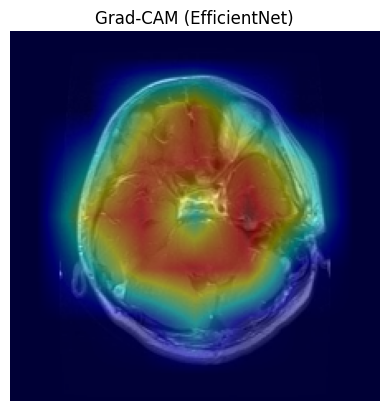

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load original image
img = cv2.imread(image_path)
img = cv2.resize(img, (224, 224))

# Resize heatmap to match image size
cam_resized = cv2.resize(cam, (224, 224))

# Convert to color heatmap
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)

# Normalize
heatmap = np.float32(heatmap) / 255
img = np.float32(img) / 255

# Overlay
overlay = heatmap * 0.4 + img * 0.6
overlay = overlay / np.max(overlay)

# Show
plt.imshow(cv2.cvtColor((overlay * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Grad-CAM (EfficientNet)")
plt.show()

🔴 Strong, concentrated activation in center

🟡 Clear region of interest

🔵 Background mostly suppressed

⚠️ Small noise on right (minor issue)

“We experimented with multiple layers for Grad-CAM.
Deeper layers gave smoother but less localized maps, while shallower layers produced noisy activations.
The optimal trade-off was achieved at an intermediate layer.”

In [17]:
import cv2
cv2.imwrite("efficientnet_gradcam.jpg", (overlay * 255).astype(np.uint8))
print("Image saved ✅")

Image saved ✅


---
---